In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [90]:
def create_dataset_df(num_series=100000, series_length=1000):
    """
    Создание датасета, содержащего временные ряды разных типов в виде DataFrame.
    
    Параметры:
    - num_series: int, количество временных рядов каждого типа
    - series_length: int, длина каждого временного ряда
    
    Возвращает:
    - dataset: dict, содержащий временные ряды разных типов в виде DataFrame
    """
    dataset = {}
    
    # Создание авторегрессионных временных рядов с малой памятью
    ar2_series = []
    for _ in range(num_series):
        time_series = generate_arma(p=2, q=0, n=series_length)
        ar2_series.append(time_series)
    dataset['ar2'] = pd.DataFrame(ar2_series)
    
    # Создание авторегрессионных временных рядов с большой памятью
    arma_series = []
    for _ in range(num_series):
        time_series = generate_arma(p=10, q=5, n=series_length)
        arma_series.append(time_series)
    dataset['arma'] = pd.DataFrame(arma_series)
    
    # Создание мультифрактальных временных рядов
    multifractal_series = []
    for _ in range(num_series):
        time_series = generate_multifractal(series_length, H=np.random.rand())
        multifractal_series.append(time_series)
    dataset['multifractal'] = pd.DataFrame(multifractal_series)
    
    # Создание трендовых временных рядов
    cos_series = []
    for _ in range(num_series):
        time_series = generate_trend_series(length=series_length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.3,high=1.5))
        cos_series.append(time_series)
    dataset['trend_cos'] = pd.DataFrame(cos_series)
    
    # Создание случайных блужданий
    rand_wolk_series = []
    for _ in range(num_series):
        time_series = generate_rw(series_length)
        rand_wolk_series.append(time_series)
    dataset['random_walk'] = pd.DataFrame(multifractal_series)
    
    return dataset

# Создание датасета
dataset_df = create_dataset_df(num_series=100, series_length=500)


In [96]:
def calculate_characteristics(dataset_df):
    """
    Вычисление характеристик для каждого временного ряда в датасете и сохранение их в датафрейме.
    
    Параметры:
    - dataset_df: dict, содержащий временные ряды разных типов в виде DataFrame
    
    Возвращает:
    - characteristics_df: DataFrame, содержащий характеристики для каждого временного ряда
    """
    characteristics = {}
    
    # Вычисление характеристик для каждого типа временного ряда
    for key, df in dataset_df.items():
        print(key)
        characteristics[key + '_stationary4'] = df.apply(permutation_stationary_entropy, args=(4,), axis=1)
        characteristics[key + '_ent_rate4'] = df.apply(permutation_entropy_rate, args=(4,1,), axis=1)
        characteristics[key + '_ent_rate4_5_jump'] = df.apply(permutation_entropy_rate, args=(4,5,), axis=1)
        characteristics[key + '_ent_rate4_10_jump'] = df.apply(permutation_entropy_rate, args=(4,10,), axis=1)
        characteristics[key + '_perm_ent4'] = df.apply(permutation_entropy, args=(4,), axis=1)
        
        
    # Создание датафрейма с характеристиками
    characteristics_df = pd.DataFrame(characteristics)
    
    return characteristics_df

# Вычисление характеристик для датасета
characteristics_df = calculate_characteristics(dataset_df)

ar2
arma
multifractal
trend_cos
random_walk


In [97]:
characteristics_df.head()

,ar2_stationary4,ar2_ent_rate4,ar2_ent_rate4_5_jump,ar2_ent_rate4_10_jump,ar2_perm_ent4,arma_stationary4,arma_ent_rate4,arma_ent_rate4_5_jump,arma_ent_rate4_10_jump,arma_perm_ent4,...,trend_cos_stationary4,trend_cos_ent_rate4,trend_cos_ent_rate4_5_jump,trend_cos_ent_rate4_10_jump,trend_cos_perm_ent4,random_walk_stationary4,random_walk_ent_rate4,random_walk_ent_rate4_5_jump,random_walk_ent_rate4_10_jump,random_walk_perm_ent4
0,4.505766,3.262172,4.794032,4.843775,4.505136,3.741451,3.523538,6.001695,6.475659,3.750302,...,4.546843,3.332516,4.703377,4.710254,4.548431,4.188492,3.802734,5.913524,5.914253,4.181924
1,4.532262,3.227088,4.736471,4.760236,4.532234,4.169584,2.515335,4.808661,5.429374,4.178484,...,2.457516,3.023138,6.628281,6.614650,2.448244,4.269586,3.793577,5.643839,5.647763,4.271684
2,4.304460,3.293289,5.292589,5.462472,4.301409,4.114489,3.944114,6.200000,6.200667,4.116224,...,4.514085,3.407111,4.824005,4.830375,4.514311,4.270280,3.801479,5.630031,5.633022,4.275152
3,4.346615,2.868947,4.984100,5.274511,4.347059,4.506452,3.240044,4.725711,4.834125,4.506498,...,4.265469,3.764066,5.639610,5.663685,4.264574,4.123846,3.943087,6.131109,6.133130,4.127411
4,4.381638,3.138268,5.142661,5.234026,4.379947,4.312620,3.560250,5.279312,5.434120,4.314419,...,3.772928,3.860027,7.180665,7.186345,3.768040,4.239823,3.916619,5.788034,5.788976,4.243251


In [98]:
characteristics_df.to_csv("../src/feature/artifical.csv")

In [99]:
characteristics_df = pd.read_csv("../src/feature/artifical.csv", index_col=0)

<Axes: >

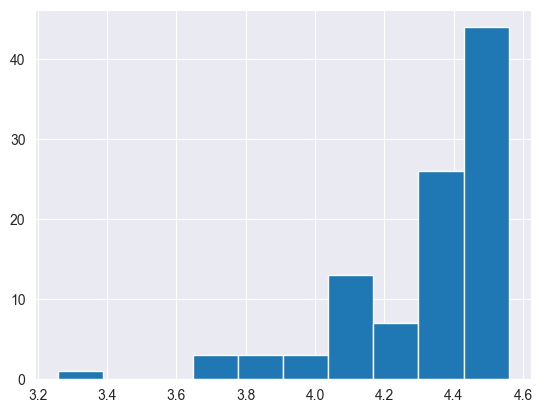

In [100]:
characteristics_df["ar2_stationary4"].hist()

<Axes: >

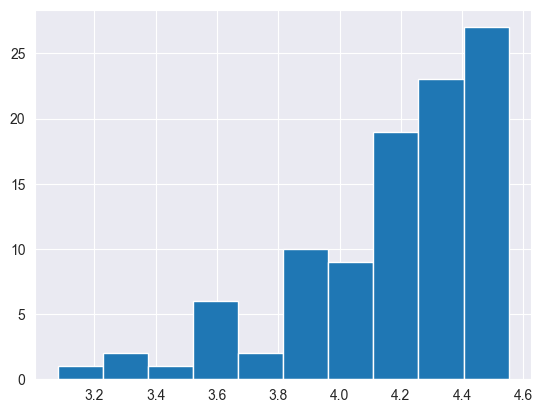

In [101]:
characteristics_df["arma_stationary4"].hist()

<Axes: >

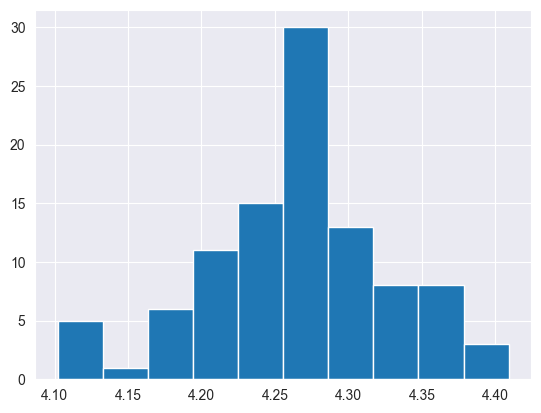

In [102]:
characteristics_df["multifractal_stationary4"].hist()

<Axes: >

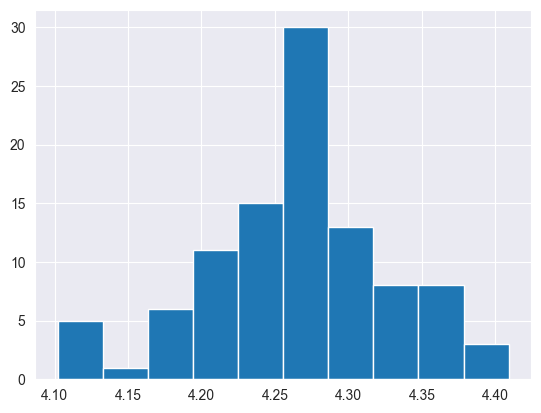

In [103]:
characteristics_df["random_walk_stationary4"].hist()

<Axes: >

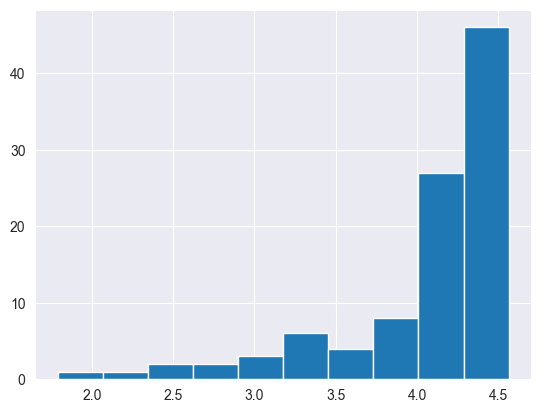

In [104]:
characteristics_df["trend_cos_stationary4"].hist()

<Axes: >

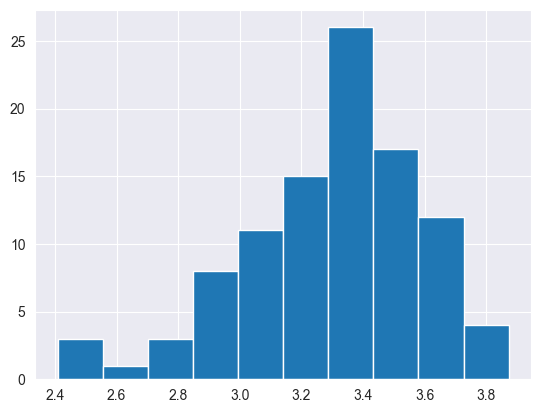

In [105]:
characteristics_df["ar2_ent_rate4"].hist()

<Axes: >

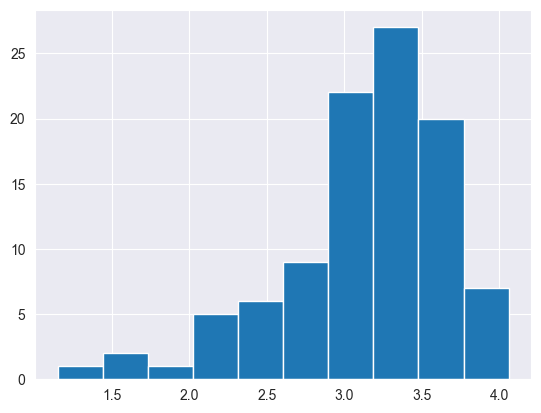

In [106]:
characteristics_df["arma_ent_rate4"].hist()

<Axes: >

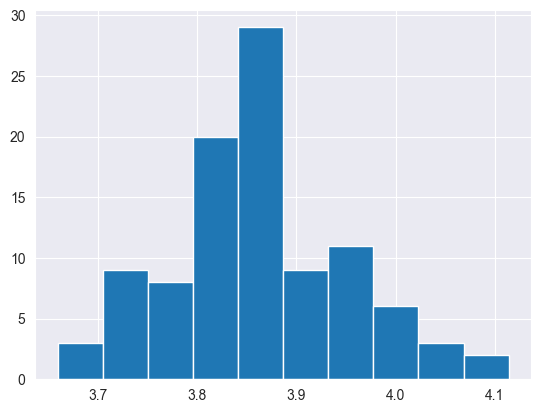

In [107]:
characteristics_df["random_walk_ent_rate4"].hist()

<Axes: >

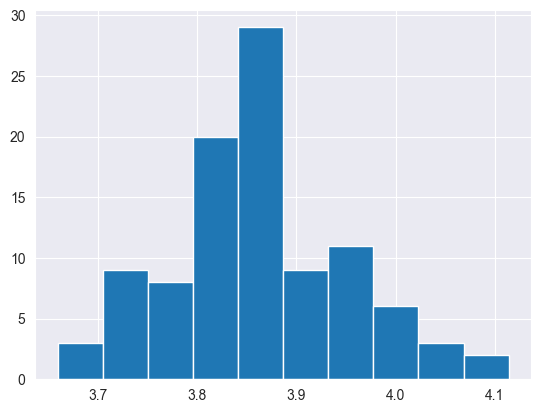

In [108]:
characteristics_df["multifractal_ent_rate4"].hist()

<Axes: >

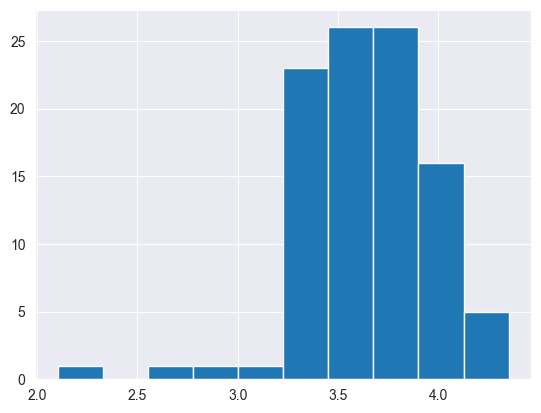

In [109]:
characteristics_df["trend_cos_ent_rate4"].hist()

<Axes: xlabel='value', ylabel='Count'>

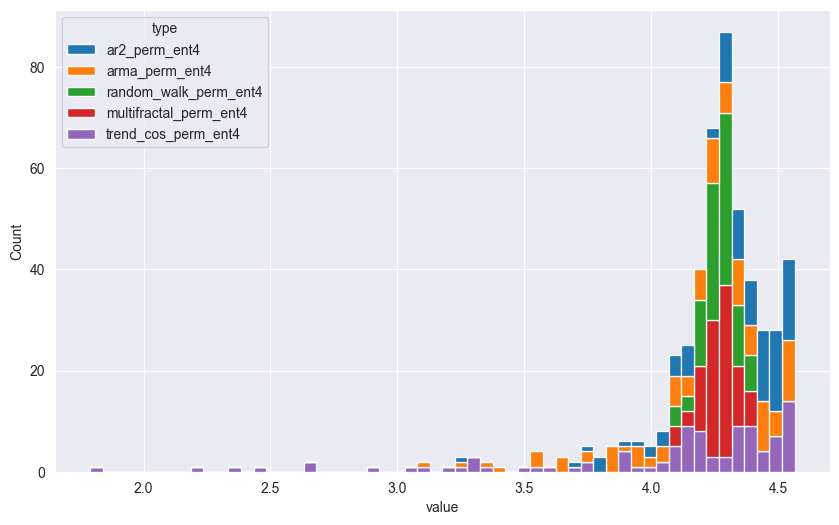

In [110]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_perm_ent4", "arma_perm_ent4", "random_walk_perm_ent4", "multifractal_perm_ent4", "trend_cos_perm_ent4"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

<Axes: xlabel='value', ylabel='Count'>

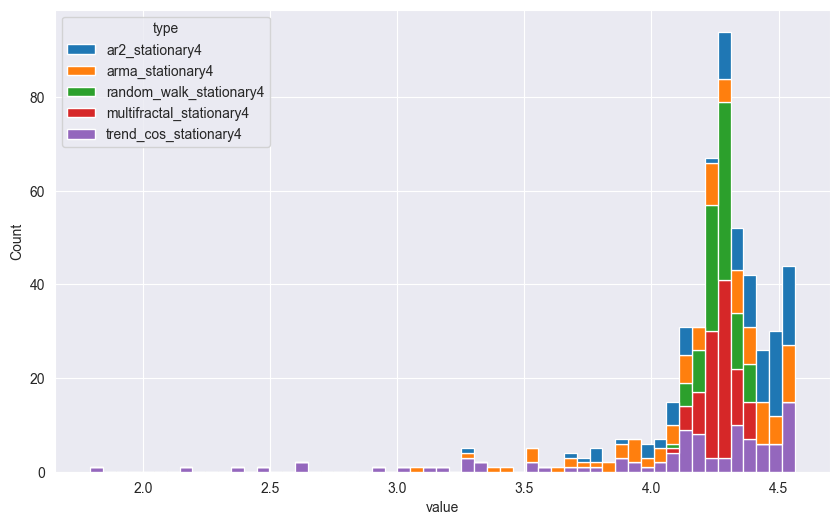

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_stationary4", "arma_stationary4", "random_walk_stationary4", "multifractal_stationary4", "trend_cos_stationary4"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

<Axes: xlabel='value', ylabel='Count'>

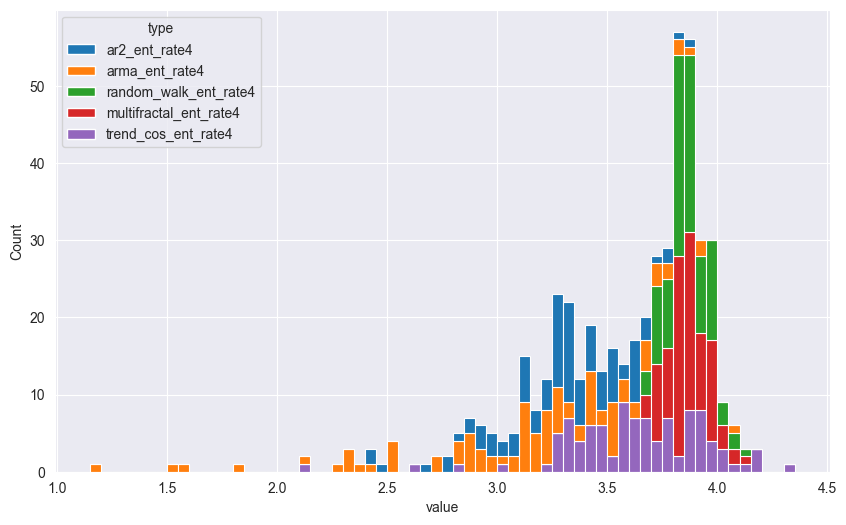

In [112]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_ent_rate4", "arma_ent_rate4", "random_walk_ent_rate4", "multifractal_ent_rate4", "trend_cos_ent_rate4"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

<Axes: xlabel='value', ylabel='Count'>

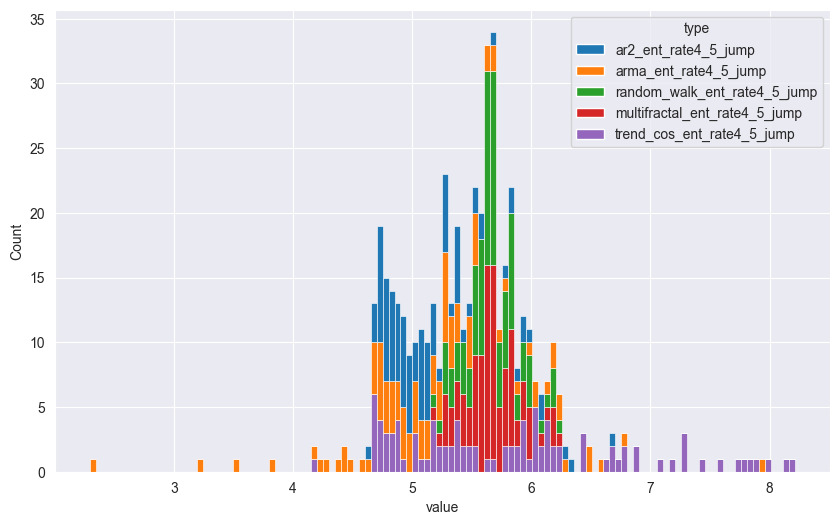

In [113]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_ent_rate4_5_jump", "arma_ent_rate4_5_jump", "random_walk_ent_rate4_5_jump", "multifractal_ent_rate4_5_jump", "trend_cos_ent_rate4_5_jump"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

<Axes: xlabel='value', ylabel='Count'>

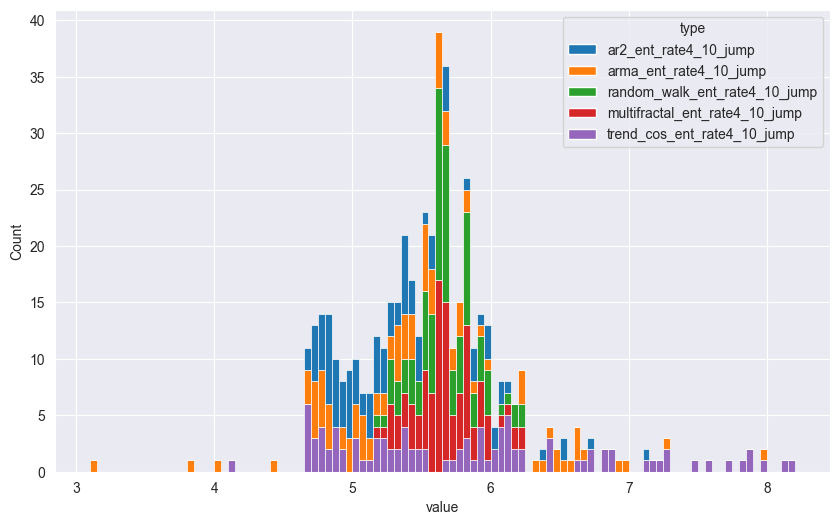

In [114]:
plt.figure(figsize=(10, 6))
sns.histplot(data=characteristics_df[["ar2_ent_rate4_10_jump", "arma_ent_rate4_10_jump", "random_walk_ent_rate4_10_jump", "multifractal_ent_rate4_10_jump", "trend_cos_ent_rate4_10_jump"]].melt(var_name="type"), x="value", binwidth=0.05, hue="type", alpha=1, multiple="stack")

In [115]:
def cutting_name(name):
    return name.split('_')[0]

df1=characteristics_df[["ar2_ent_rate4_5_jump", "arma_ent_rate4_5_jump", "random_walk_ent_rate4_5_jump", "multifractal_ent_rate4_5_jump", "trend_cos_ent_rate4_5_jump"]].melt(var_name="type")

df1['type'] = df1['type'].apply(cutting_name)
df2 = characteristics_df[["ar2_ent_rate4", "arma_ent_rate4", "random_walk_ent_rate4", "multifractal_ent_rate4", "trend_cos_ent_rate4"]].melt(var_name="type")
df = df1.copy()
df['value1'] = df2['value']
df.head()

,type,value,value1
0,ar2,4.794032,3.262172
1,ar2,4.736471,3.227088
2,ar2,5.292589,3.293289
3,ar2,4.984100,2.868947
4,ar2,5.142661,3.138268


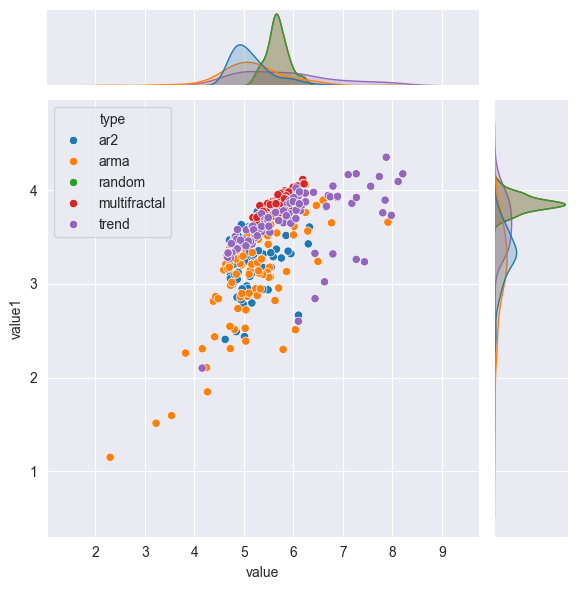

In [116]:
g = sns.jointplot(
    data=df,
    x="value", y="value1", hue="type",
    kind="scatter")

<Axes: >

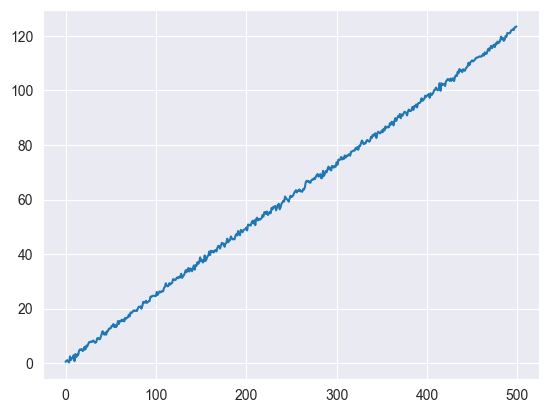

In [121]:
dataset_df["trend_cos"].loc[68].plot()